# % of Bike Commuters vs Bike Network Quality (Connectivity of LTS < 2 Subnetwork)

In [2]:
%%capture
pip install osmnx

In [3]:
%%capture
pip install --pre pycen==0.1.0a4

In [4]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox
import networkx as nx
from pycen import acquire

plt.style.use('seaborn-v0_8')

PLACE = "Berkeley, California, USA"
YEARS = [2014, 2019]
DATASET = "acs5"

variables = {
    "B08301_001E": "workers_total",
    "B08301_008E": "bike_commute"
}

print("Libraries imported.")

Libraries imported.


## 1. Download Berkeley bike network

In [5]:
# G_bike = ox.graph_from_place(PLACE, network_type="bike", simplify=True)
# print(f"Bike network nodes: {G_bike.number_of_nodes():,}")
# print(f"Bike network edges: {G_bike.number_of_edges():,}")

## 2. Compute bike quality metric

In [6]:
#

## 3. Download ACS bike commute share for Berkeley tracts

We pull tract-level data for two years and compute the percentage of workers who commute by bicycle.

In [7]:
tracts_by_year = []
for year in YEARS:
    gdf = acquire.get_censhp(
        variables=variables,
        geography="tract",
        place="Berkeley",
        state="CA",
        year=year,
        dataset=DATASET,
        add_area=True
    )
    gdf.replace(-666666666, np.nan, inplace=True)
    gdf["pct_bike"] = gdf["bike_commute"] / gdf["workers_total"] * 100
    gdf["year"] = year
    tracts_by_year.append(gdf.to_crs("EPSG:4326"))

tracts = gpd.GeoDataFrame(pd.concat(tracts_by_year, ignore_index=True), crs="EPSG:4326")

Resolving geography...
  State: California (CA, FIPS: 06)

Fetching data...
  Product: acs5 (2014)
  Geography: Tract
  Variables: 2


Downloading: 100%|██████████| 1/1 [00:00<00:00,  1.14it/s]


Fetching boundaries...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...

Done!
Resolving geography...
  State: California (CA, FIPS: 06)

Fetching data...
  Product: acs5 (2019)
  Geography: Tract
  Variables: 2


Downloading: 100%|██████████| 1/1 [00:00<00:00,  1.03it/s]


Fetching boundaries...
Merging data...
Clipping to place: Berkeley
Fetching boundaries...

Done!


## 4. Aggregate bike network quality to census tracts

In [ ]:
# nodes_in_tract = gpd.sjoin(
#     nodes_gdf,
#     tracts[["geometry"]],
#     how="inner",
#     predicate="within"
# )
# centrality_by_tract = nodes_in_tract.groupby("index_right")["betweenness"].mean()
# tracts["betweenness"] = centrality_by_tract
# tracts["betweenness"] = tracts["betweenness"].fillna(0)

# print(f"Tracts with centrality values: {tracts['betweenness'].gt(0).sum()} / {len(tracts)}")

## 5. Scatter plot: betweenness centrality vs. bike commute share

This plot shows each tract's mean bike-network centrality against the percentage of workers commuting by bicycle.

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 6))
# for year, group in tracts.groupby("year"):
#     group = group.dropna(subset=["betweenness", "pct_bike"])
#     ax.scatter(
#         group["betweenness"],
#         group["pct_bike"],
#         alpha=0.75,
#         s=60,
#         label=str(year)
#     )

# ax.set_xlabel("Mean Bike-Network Betweenness Centrality (tract)")
# ax.set_ylabel("% Workers Commuting by Bicycle")
# ax.set_title("Berkeley Census Tracts: Bike Commute Share vs. Bike Network Betweenness")
# ax.legend(title="ACS Year")
# ax.grid(True, linestyle=':', alpha=0.5)
# plt.tight_layout()
# plt.show()

In [21]:
range = len(group.dropna(subset=["pct_bike"]))

Replace QUALITY_METRIC with correct label

KeyError: ['QUALITY_METRIC']

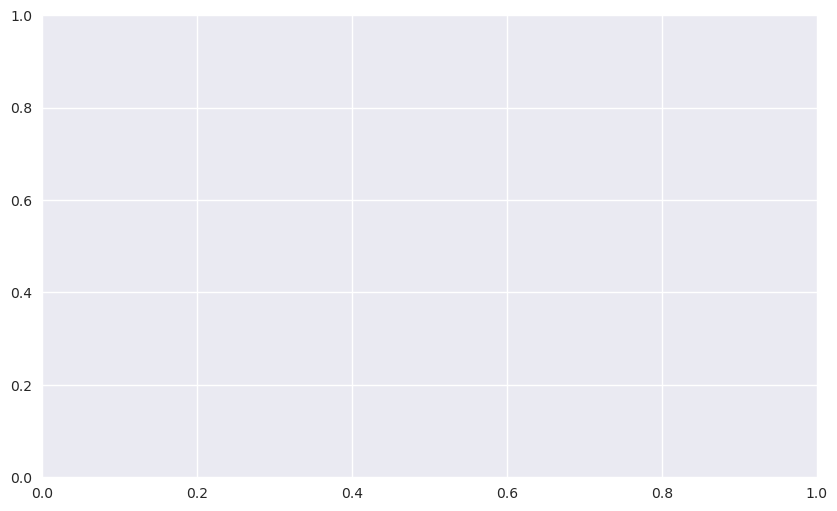

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
for year, group in tracts.groupby("year"):
    group = group.dropna(subset=["QUALITY_METRIC", "pct_bike"])
    ax.scatter(
        group["QUALITY_METRIC"],
        group["pct_bike"],
        alpha=0.75,
        s=60,
        label=str(year)
    )

ax.set_xlabel("Bike Network Quality (LCC for LTS < 2 subnetwork)")
ax.set_ylabel("% Workers Commuting by Bicycle")
ax.set_title("Berkeley Census Tracts: Bike Commute Share vs. Bike Network Quality")
ax.legend(title="ACS Year")
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()